In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Adjust options
pd.set_option('display.max_columns', None)

## 1. Load Data
Baca dataset/merged_data_v1.csv dan dataset-libur-nasional-dan-weekend.csv.

In [2]:
# Paths
merged_data_path = 'dataset/merged_data_v1.csv'
holiday_data_path = '../dataset/libur-nasional/dataset-libur-nasional-dan-weekend.csv'

# Check if files exist
if not os.path.exists(merged_data_path):
    print(f"File not found: {merged_data_path}")
else:
    df_main = pd.read_csv(merged_data_path)
    print(f"Loaded merged_data_v1: {df_main.shape}")

if not os.path.exists(holiday_data_path):
    print(f"File not found: {holiday_data_path}")
else:
    df_holiday = pd.read_csv(holiday_data_path)
    print(f"Loaded holiday data: {df_holiday.shape}")

Loaded merged_data_v1: (15412, 37)
Loaded holiday data: (5844, 5)


In [3]:
# Convert date columns to datetime
# Assuming 'tanggal' is the common column. Adjust if necessary after inspecting data.
if 'tanggal' in df_main.columns:
    df_main['tanggal'] = pd.to_datetime(df_main['tanggal'])
    print("Converted df_main['tanggal'] to datetime.")
elif 'date' in df_main.columns:
    df_main['tanggal'] = pd.to_datetime(df_main['date'])
    print("Created 'tanggal' from 'date' in df_main.")

if 'tanggal' in df_holiday.columns:
    df_holiday['tanggal'] = pd.to_datetime(df_holiday['tanggal'])
    print("Converted df_holiday['tanggal'] to datetime.")

Converted df_main['tanggal'] to datetime.
Converted df_holiday['tanggal'] to datetime.


## 2. Merging
Lakukan LEFT JOIN antara merged_data_v1 (Left) dan data libur (Right) berdasarkan tanggal.
Isi nilai NaN pada kolom is_holiday_nasional dan is_weekend dengan 0.

In [4]:
# Left join
df_merged = pd.merge(df_main, df_holiday, on='tanggal', how='left')

# Fill NaN for holiday/weekend columns with 0
cols_to_fill = ['is_holiday_nasional', 'is_weekend']
for col in cols_to_fill:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna(0)
    else:
        print(f"Warning: {col} not found in merged dataframe")

print(f"Merged shape: {df_merged.shape}")
print(df_merged[['tanggal', 'is_weekend', 'is_holiday_nasional']].head())

Merged shape: (15412, 41)
     tanggal  is_weekend  is_holiday_nasional
0 2010-01-01         0.0                  1.0
1 2010-01-02         1.0                  0.0
2 2010-01-03         1.0                  0.0
3 2010-01-04         0.0                  0.0
4 2010-01-05         0.0                  0.0


## 3. Feature Engineering (Mobilitas)
Buat fitur baru: `is_working_day`.
Logika: Jika `is_weekend` == 0 DAN `is_holiday_nasional` == 0, maka 1. Selain itu 0.

In [5]:
def determine_working_day(row):
    # Ensure values are numeric for comparison
    is_weekend = float(row['is_weekend'])
    is_holiday = float(row['is_holiday_nasional'])
    
    if is_weekend == 0 and is_holiday == 0:
        return 1
    return 0

df_merged['is_working_day'] = df_merged.apply(determine_working_day, axis=1)

# Check distribution
print("Distribution of is_working_day:")
print(df_merged['is_working_day'].value_counts())

Distribution of is_working_day:
is_working_day
1    10576
0     4836
Name: count, dtype: int64


## 4. Analisis Dampak (Hypothesis Testing)
Hitung rata-rata pm10 berdasarkan kategori.

In [6]:
# Define pollutant column (e.g., pm10)
pollutant = 'pm10' # Adjust if different name
if pollutant not in df_merged.columns and 'PM10' in df_merged.columns:
    pollutant = 'PM10'

if pollutant in df_merged.columns:
    print(f"Analyzing {pollutant}")
    
    # Group 1: Weekend vs Weekday
    print("\nWeekend vs Weekday:")
    print(df_merged.groupby('is_weekend')[pollutant].mean())

    # Group 2: Holiday vs Non-Holiday
    print("\nHoliday vs Non-Holiday:")
    print(df_merged.groupby('is_holiday_nasional')[pollutant].mean())

    # Group 3: Working Day vs Non-Working Day
    print("\nWorking Day vs Non-Working Day:")
    print(df_merged.groupby('is_working_day')[pollutant].mean())
else:
    print(f"{pollutant} column not found. Available columns: {df_merged.columns.tolist()}")

Analyzing pm10

Weekend vs Weekday:
is_weekend
0.0    53.884833
1.0    54.651061
Name: pm10, dtype: float64

Holiday vs Non-Holiday:
is_holiday_nasional
0.0    54.198675
1.0    52.001493
Name: pm10, dtype: float64

Working Day vs Non-Working Day:
is_working_day
0    54.389624
1    53.965729
Name: pm10, dtype: float64


## 5. Visualisasi
Buat Boxplot sederhana yang membandingkan distribusi pm10 pada Working Day vs Non-Working Day.

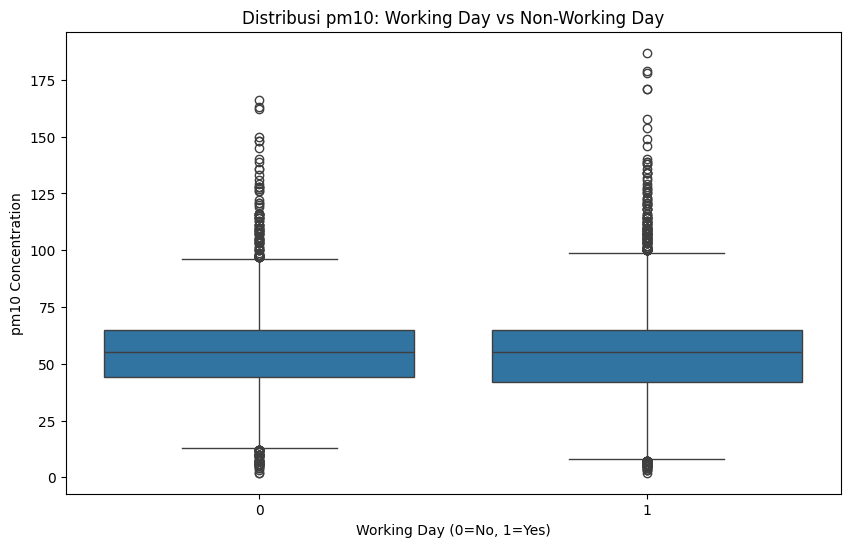

In [7]:
if pollutant in df_merged.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='is_working_day', y=pollutant, data=df_merged)
    plt.title(f'Distribusi {pollutant}: Working Day vs Non-Working Day')
    plt.xlabel('Working Day (0=No, 1=Yes)')
    plt.ylabel(f'{pollutant} Concentration')
    plt.show()

/tmp/ipykernel_39247/2336831036.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_holiday_nasional', y=pollutant, data=df_merged, palette='Set2')
/tmp/ipykernel_39247/2336831036.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_weekend', y=pollutant, data=df_merged, palette='Set3')


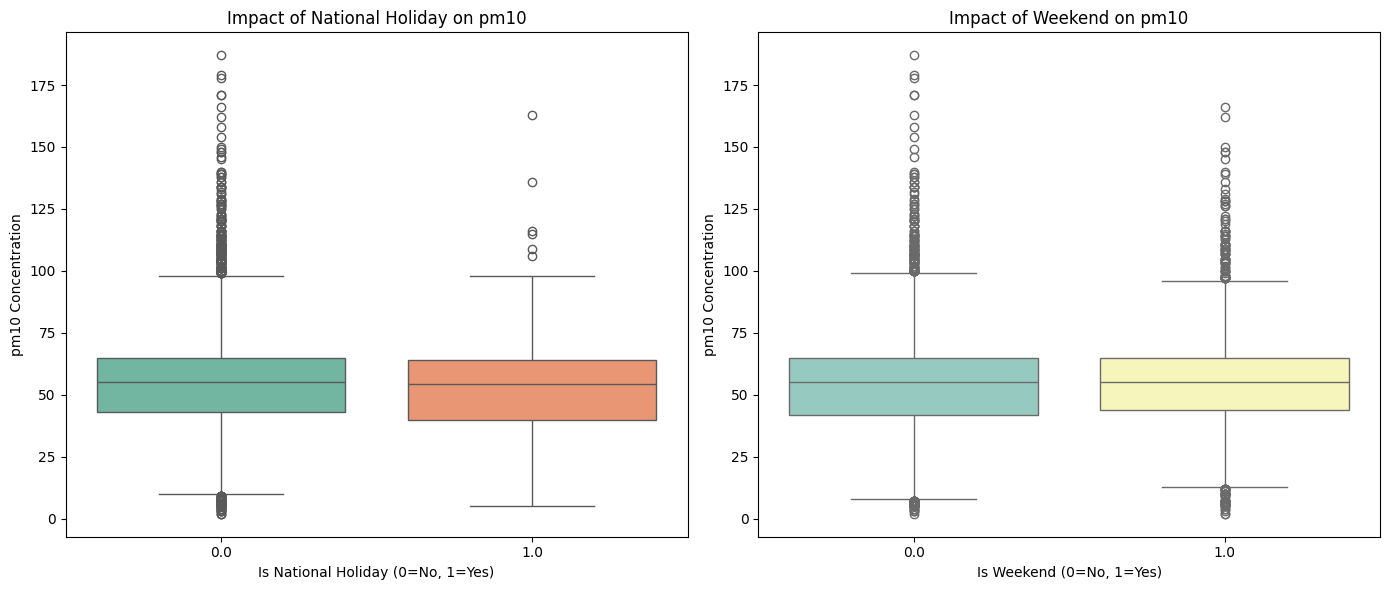

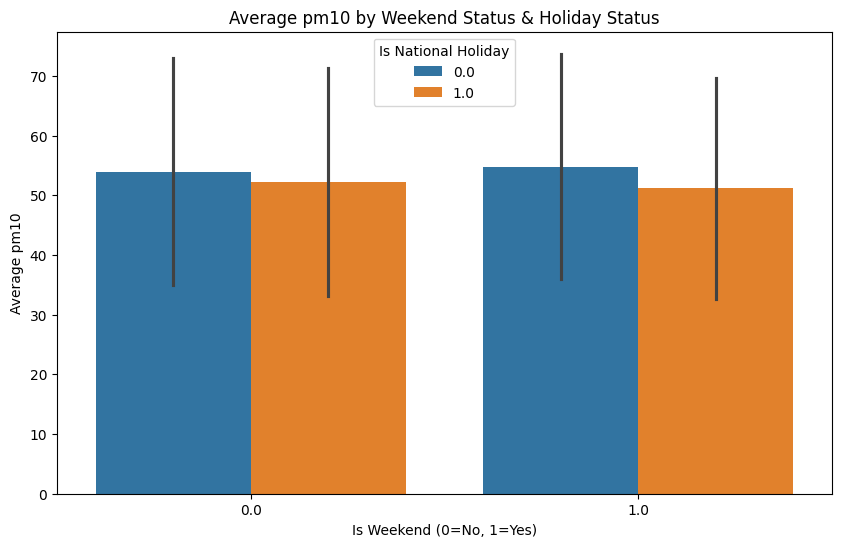

In [ ]:
# Visualisasi Dampak Langsung Libur Nasional & Weekend
if pollutant in df_merged.columns:
    plt.figure(figsize=(14, 6))

    # Plot 1: Holiday vs Non-Holiday
    plt.subplot(1, 2, 1)
    sns.boxplot(x='is_holiday_nasional', y=pollutant, data=df_merged, hue='is_holiday_nasional', legend=False, palette='Set2')
    plt.title(f'Impact of National Holiday on {pollutant}')
    plt.xlabel('Is National Holiday (0=No, 1=Yes)')
    plt.ylabel(f'{pollutant} Concentration')

    # Plot 2: Weekend vs Weekday
    plt.subplot(1, 2, 2)
    sns.boxplot(x='is_weekend', y=pollutant, data=df_merged, hue='is_weekend', legend=False, palette='Set3')
    plt.title(f'Impact of Weekend on {pollutant}')
    plt.xlabel('Is Weekend (0=No, 1=Yes)')
    plt.ylabel(f'{pollutant} Concentration')

    plt.tight_layout()
    plt.show()

    # Bar plot for interaction
    plt.figure(figsize=(10, 6))
    sns.barplot(x='is_weekend', y=pollutant, hue='is_holiday_nasional', data=df_merged, errorbar='sd')
    plt.title(f'Average {pollutant} by Weekend Status & Holiday Status')
    plt.xlabel('Is Weekend (0=No, 1=Yes)')
    plt.ylabel(f'Average {pollutant}')
    plt.legend(title='Is National Holiday')
    plt.show()

Visualizing impact on category column: target_kategori

--- Proportion by Holiday Status (0=No, 1=Yes) ---
target_kategori          BAIK  BERBAHAYA  SANGAT TIDAK SEHAT    SEDANG  \
is_holiday_nasional                                                      
0.0                  0.149531   0.000068            0.013124  0.678839   
1.0                  0.202550   0.000000            0.009915  0.658640   

target_kategori      TIDAK SEHAT  
is_holiday_nasional               
0.0                     0.158439  
1.0                     0.128895  

--- Proportion by Weekend Status (0=No, 1=Yes) ---
target_kategori      BAIK  BERBAHAYA  SANGAT TIDAK SEHAT    SEDANG  \
is_weekend                                                           
0.0              0.153223   0.000000            0.013054  0.671858   
1.0              0.148699   0.000232            0.012779  0.693541   

target_kategori  TIDAK SEHAT  
is_weekend                    
0.0                 0.161865  
1.0                 0.144749  

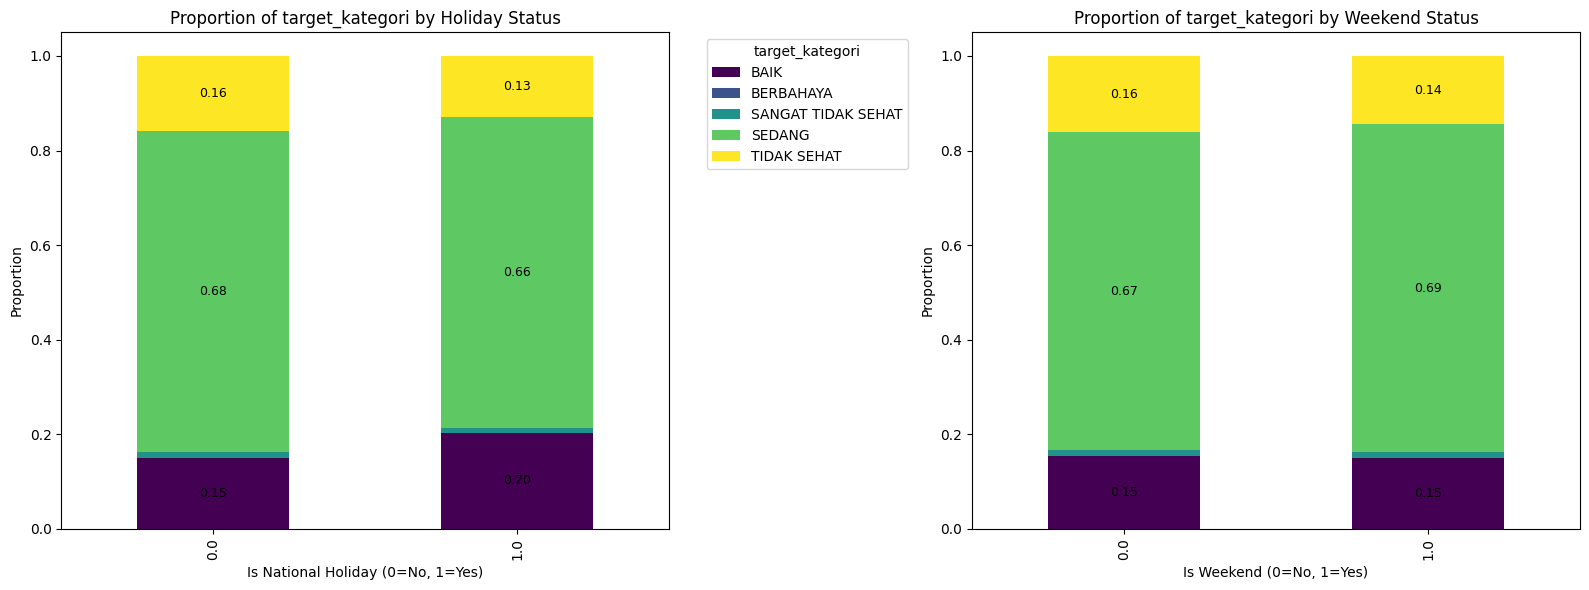

In [14]:
# Visualisasi Dampak Hari Libur terhadap Kategori ISPU
# Mencari kolom kategori yang sesuai
cat_col = None
possible_cols = ['target_kategori', 'categori', 'kategori', 'category', 'ispu_category']
for col in possible_cols:
    if col in df_merged.columns:
        cat_col = col
        break

if cat_col:
    print(f"Visualizing impact on category column: {cat_col}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Helper function to add labels
    def add_value_labels(ax):
        for c in ax.containers:
            # Customize label: format as %.2f, center in bar
            # Only label if value is greater than a small threshold to avoid clutter
            labels = [f'{v:.2f}' if v > 0.05 else '' for v in c.datavalues]
            ax.bar_label(c, labels=labels, label_type='center', fontsize=9)

    # Plot 1: Holiday vs Non-Holiday (Stacked Bar)
    # Crosstab with normalization to show proportions
    ct_holiday = pd.crosstab(df_merged['is_holiday_nasional'], df_merged[cat_col], normalize='index')
    
    print("\n--- Proportion by Holiday Status (0=No, 1=Yes) ---")
    print(ct_holiday)
    
    ct_holiday.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
    axes[0].set_title(f'Proportion of {cat_col} by Holiday Status')
    axes[0].set_xlabel('Is National Holiday (0=No, 1=Yes)')
    axes[0].set_ylabel('Proportion')
    axes[0].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    add_value_labels(axes[0])

    # Plot 2: Weekend vs Weekday (Stacked Bar)
    ct_weekend = pd.crosstab(df_merged['is_weekend'], df_merged[cat_col], normalize='index')
    
    print("\n--- Proportion by Weekend Status (0=No, 1=Yes) ---")
    print(ct_weekend)
    
    ct_weekend.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
    axes[1].set_title(f'Proportion of {cat_col} by Weekend Status')
    axes[1].set_xlabel('Is Weekend (0=No, 1=Yes)')
    axes[1].set_ylabel('Proportion')
    axes[1].get_legend().remove() # Determine if we need legend for both or just one
    add_value_labels(axes[1])

    plt.tight_layout()
    plt.show()
else:
    print(f"Category column not found. Available columns: {df_merged.columns.tolist()}")

## 6. Output
Simpan sebagai dataset/merged_data_v2.csv.

In [8]:
output_path = 'dataset/merged_data_v2.csv'
# Ensure directory exists (it should, as we read from it)
df_merged.to_csv(output_path, index=False)
print(f"Saved merged data to {output_path}")

# Display summary table
if pollutant in df_merged.columns:
    summary = df_merged.groupby(['is_working_day', 'is_weekend', 'is_holiday_nasional'])[pollutant].mean().reset_index()
    print("\nSummary Table:")
    print(summary)

Saved merged data to dataset/merged_data_v2.csv

Summary Table:
   is_working_day  is_weekend  is_holiday_nasional       pm10
0               0         0.0                  1.0  52.270751
1               0         1.0                  0.0  54.796038
2               0         1.0                  1.0  51.170732
3               1         0.0                  0.0  53.965729
